# README - Análise de Modelos Lineares Mistos em Python

Este notebook replica, em Python, toda a análise estatística do arquivo `Modelo Linear Misto.Rmd` (R Markdown), utilizada para investigar fatores preditores das demandas físicas de jogadores na Copa do Mundo de Clubes (FCWC).

**Objetivo:**
- Analisar, por meio de modelos lineares mistos, o efeito de variáveis ambientais, demográficas e de jogo sobre a demanda física dos jogadores.
- Reproduzir todas as etapas do script original em R, incluindo tratamento de dados, análise descritiva, modelagem, diagnóstico e visualização.

**Estrutura do notebook:**
1. README e comentários iniciais
2. Importação das bibliotecas necessárias
3. Carregamento e tratamento dos dados
4. Análise descritiva
5. Centralização das variáveis numéricas
6. Modelagem linear mista
7. Comparação dos modelos (AIC, BIC, R²)
8. Tabelas de resultados dos modelos
9. Análise dos pressupostos do modelo
10. Visualização de relações entre variáveis
11. Análise de efeitos marginais estimados

**Instruções:**
- Certifique-se de ter o arquivo Excel de dados na pasta correta (`data/`).
- Instale as bibliotecas necessárias antes de rodar o notebook.
- Todas as células estão comentadas para facilitar o entendimento e adaptação.


In [1]:
# Importação das bibliotecas necessárias
# Todas as bibliotecas abaixo são utilizadas para replicar as análises do arquivo Rmd em Python.
# Execute esta célula após instalar os pacotes necessários (use pip install <pacote> se necessário).

import pandas as pd  # Manipulação de dados
import numpy as np  # Operações numéricas
import matplotlib.pyplot as plt  # Gráficos
import seaborn as sns  # Visualização de dados
import statsmodels.api as sm  # Modelos estatísticos
import statsmodels.formula.api as smf  # Modelos com fórmulas
from statsmodels.regression.mixed_linear_model import MixedLM  # Modelos lineares mistos
import pingouin as pg  # Estatísticas descritivas e correlações
from tabulate import tabulate  # Tabelas formatadas
from openpyxl import load_workbook  # Leitura de arquivos Excel
from sklearn.preprocessing import StandardScaler  # Centralização de variáveis
from scipy.stats import shapiro, kstest, norm  # Testes de normalidade
import warnings  # Gerenciamento de avisos
warnings.filterwarnings('ignore')  # Opcional: suprime avisos para facilitar leitura


In [2]:
# Carregamento e tratamento dos dados
# Esta célula carrega o arquivo Excel com os dados e realiza o pré-processamento conforme o script em R.

# Caminho do arquivo de dados (ajuste se necessário)
data_path = '../data/(Jul_25) Dados demandas físicas FCWC 2025.xlsx'

# Leitura dos dados
df = pd.read_excel(data_path)

# Conversão de variáveis categóricas
df['Stage'] = df['Stage'].astype('category')
df['Time_of_day'] = df['Time_of_day'].astype('category')
df['Time_of_day'] = df['Time_of_day'].cat.set_categories(['Afternoon', 'Night'], ordered=True)
df['Origin_climate'] = df['Origin_climate'].astype('category')
df['Player_id'] = df['Player_id'].astype('category')
df['Player_position'] = df['Player_position'].astype('category')
df['Player_position'] = df['Player_position'].cat.set_categories(['DF', 'MF', 'FW'], ordered=True)

# Conversão de colunas numéricas
df['Played_minutes'] = pd.to_numeric(df['Played_minutes'], errors='coerce')
df['WBGT'] = pd.to_numeric(df['WBGT'], errors='coerce')
df['Ranking_difference'] = pd.to_numeric(df['Ranking_difference'], errors='coerce')
df['Zone45_min'] = pd.to_numeric(df['Zone45_min'], errors='coerce')

# Filtros conforme o Rmd
df = df[df['Stadium_type'] != 'Closed']  # Remove jogos em estádio fechado
df = df[df['Played_minutes'] >= 60]  # Remove jogadores com menos de 60 minutos
df = df.reset_index(drop=True)  # Corrige o índice após os filtros


# Visualização inicial dos dados
print(df.head())


   N_Jogo Group/Stage  Stage       Date Local Time Time_of_day  \
0       1     Group A  Group 2025-06-14   20:00:00         NaN   
1       1     Group A  Group 2025-06-14   20:00:00         NaN   
2       1     Group A  Group 2025-06-14   20:00:00         NaN   
3       1     Group A  Group 2025-06-14   20:00:00         NaN   
4       1     Group A  Group 2025-06-14   20:00:00         NaN   

             Stadium Stadium_type                     City        Team  ...  \
0  Hard Rock Stadium         Open  Miami Gardens - Flórida  Al Ahly FC  ...   
1  Hard Rock Stadium         Open  Miami Gardens - Flórida  Al Ahly FC  ...   
2  Hard Rock Stadium         Open  Miami Gardens - Flórida  Al Ahly FC  ...   
3  Hard Rock Stadium         Open  Miami Gardens - Flórida  Al Ahly FC  ...   
4  Hard Rock Stadium         Open  Miami Gardens - Flórida  Al Ahly FC  ...   

  N_zone4e5_min   Temp    Tdew    UR      UA  RAD     V      TN      TG  \
0      0.470588  28.26  22.895  72.0  27.605  0.5  2.

In [3]:
# Carregamento e tratamento dos dados
# Esta célula carrega o arquivo Excel com os dados e realiza o pré-processamento conforme o script em R.

# Caminho do arquivo de dados (ajuste se necessário)
data_path = '../data/(Jul_25) Dados demandas físicas FCWC 2025.xlsx'

# Leitura dos dados
df = pd.read_excel(data_path)

# Conversão de variáveis categóricas
df['Stage'] = df['Stage'].astype('category')
df['Time_of_day'] = df['Time_of_day'].astype('category')
df['Time_of_day'] = df['Time_of_day'].cat.set_categories(['Afternoon', 'Night'], ordered=True)
df['Origin_climate'] = df['Origin_climate'].astype('category')
df['Player_id'] = df['Player_id'].astype('category')
df['Player_position'] = df['Player_position'].astype('category')
df['Player_position'] = df['Player_position'].cat.set_categories(['DF', 'MF', 'FW'], ordered=True)

# Conversão de colunas numéricas
df['Played_minutes'] = pd.to_numeric(df['Played_minutes'], errors='coerce')
df['WBGT'] = pd.to_numeric(df['WBGT'], errors='coerce')
df['Ranking_difference'] = pd.to_numeric(df['Ranking_difference'], errors='coerce')
df['Zone45_min'] = pd.to_numeric(df['Zone45_min'], errors='coerce')

# Filtros conforme o Rmd
df = df[df['Stadium_type'] != 'Closed']  # Remove jogos em estádio fechado
df = df[df['Played_minutes'] >= 60]      # Remove jogadores com menos de 60 minutos
df = df[df['Player_id'].notnull()]       # Remove linhas com Player_id nulo

df = df.reset_index(drop=True)           # Corrige o índice após todos os filtros

# Visualização inicial dos dados
print(df.head())

   N_Jogo Group/Stage  Stage       Date Local Time Time_of_day  \
0       1     Group A  Group 2025-06-14   20:00:00         NaN   
1       1     Group A  Group 2025-06-14   20:00:00         NaN   
2       1     Group A  Group 2025-06-14   20:00:00         NaN   
3       1     Group A  Group 2025-06-14   20:00:00         NaN   
4       1     Group A  Group 2025-06-14   20:00:00         NaN   

             Stadium Stadium_type                     City        Team  ...  \
0  Hard Rock Stadium         Open  Miami Gardens - Flórida  Al Ahly FC  ...   
1  Hard Rock Stadium         Open  Miami Gardens - Flórida  Al Ahly FC  ...   
2  Hard Rock Stadium         Open  Miami Gardens - Flórida  Al Ahly FC  ...   
3  Hard Rock Stadium         Open  Miami Gardens - Flórida  Al Ahly FC  ...   
4  Hard Rock Stadium         Open  Miami Gardens - Flórida  Al Ahly FC  ...   

  N_zone4e5_min   Temp    Tdew    UR      UA  RAD     V      TN      TG  \
0      0.470588  28.26  22.895  72.0  27.605  0.5  2.

In [4]:
# Análise descritiva geral e por grupos
# Esta célula calcula estatísticas descritivas da variável dependente e por grupos, similar ao Rmd.

# Variável alvo
target_variable = 'Total_distance_min'
grouping_variables = ['Time_of_day', 'Stage', 'Player_position', 'Origin_climate']

# Estatísticas descritivas gerais
desc_general = df[target_variable].describe()
print('Descritivas gerais:', desc_general)

# Estatísticas descritivas por grupos
for grp in grouping_variables:
    print(f'\nDescritivas por {grp}:')
    print(df.groupby(grp)[target_variable].describe())

# # (Opcional) Usar pingouin para tabelas mais detalhadas
# for grp in grouping_variables:
#     print(f'\nResumo pingouin por {grp}:')
#     print(pg.groupby_describe(df, dv=target_variable, group=grp))


Descritivas gerais: count    1070.000000
mean      103.993737
std        10.834255
min        63.564151
25%        96.645579
50%       103.416128
75%       111.140800
max       134.419318
Name: Total_distance_min, dtype: float64

Descritivas por Time_of_day:
             count      mean        std        min        25%         50%  \
Time_of_day                                                                 
Afternoon    618.0  102.8169  11.214765  63.564151  95.249243  102.355718   
Night          0.0       NaN        NaN        NaN        NaN         NaN   

                    75%         max  
Time_of_day                          
Afternoon    109.916948  134.419318  
Night               NaN         NaN  

Descritivas por Stage:
          count        mean        std        min        25%         50%  \
Stage                                                                      
Group     833.0  104.867684  10.823803  73.556436  97.439423  104.244118   
Playoffs  237.0  100.922013 

In [5]:
# Centralização das variáveis numéricas
# Esta célula centraliza as variáveis numéricas em torno da média, criando colunas com sufixo '_c'.

variaveis_para_centralizar = ['WBGT', 'Temp', 'TN', 'TG', 'UR', 'UA', 'RAD', 'Player_age']
for var in variaveis_para_centralizar:
    if var in df.columns:
        df[var + '_c'] = df[var] - df[var].mean()
    else:
        print(f'Coluna {var} não encontrada no DataFrame.')


In [6]:
# Modelagem linear mista (MixedLM)
# Esta célula ajusta modelos lineares mistos conforme especificado no arquivo Rmd.
# Utilize statsmodels MixedLM para replicar os modelos do R.

# Lista de variáveis usadas nos modelos
model_vars = [
    'Total_distance_min', 'Stage', 'Time_of_day', 'Ranking_difference', 'Player_position',
    'Player_age_c', 'Origin_climate', 'WBGT_c', 'Temp_c', 'UR_c', 'RAD_c', 'Player_id'
]

# Filtrar apenas as colunas necessárias e remover linhas com NaN
model_df = df[model_vars].dropna().copy()

# Remover categorias não usadas (importante após filtros)
for col in ['Stage', 'Time_of_day', 'Player_position', 'Origin_climate', 'Player_id']:
    model_df[col] = model_df[col].cat.remove_unused_categories()

# Checar se há colunas constantes (com apenas um valor)
print('Valores únicos por coluna:')
print(model_df.nunique())

# MODELO 1
mixed_model1 = None
print("Resultados do Modelo 1")
try:
    mixed_model1 = smf.mixedlm(
        "Total_distance_min ~ Stage + Time_of_day + Ranking_difference + Player_position + Player_age_c + Origin_climate + WBGT_c + Time_of_day * WBGT_c",
        data=model_df,
        groups=model_df["Player_id"],
        re_formula="~1"
    ).fit(reml=False)
    print(mixed_model1.summary())
except Exception as e:
    print(f"Erro ao ajustar Modelo 1: {e}")
print("\n" + "="*50 + "\n")

# MODELO 2
mixed_model2 = None
print("Resultados do Modelo 2")
try:
    mixed_model2 = smf.mixedlm(
        "Total_distance_min ~ Stage + Time_of_day + Ranking_difference + Player_position + Player_age_c + Origin_climate + Temp_c + UR_c + RAD_c + Time_of_day * Temp_c + Time_of_day * UR_c",
        data=model_df,
        groups=model_df["Player_id"],
        re_formula="~1"
    ).fit(reml=False)
    print(mixed_model2.summary())
except Exception as e:
    print(f"Erro ao ajustar Modelo 2: {e}")
print("\n" + "="*50 + "\n")

# MODELO 3 (anteriormente MODELO 5)
mixed_model3 = None
print("Resultados do Modelo 3")
try:
    mixed_model3 = smf.mixedlm(
        "Total_distance_min ~ Stage + Time_of_day + Ranking_difference + Player_position + Player_age_c + Origin_climate + WBGT_c + UR_c + Time_of_day * UR_c + Time_of_day * WBGT_c",
        data=model_df,
        groups=model_df["Player_id"],
        re_formula="~1"
    ).fit(reml=False)
    print(mixed_model3.summary())
except Exception as e:
    print(f"Erro ao ajustar Modelo 3: {e}")
print("\n" + "="*50 + "\n")


Valores únicos por coluna:
Total_distance_min    617
Stage                   2
Time_of_day             1
Ranking_difference     40
Player_position         3
Player_age_c          323
Origin_climate          2
WBGT_c                 33
Temp_c                 33
UR_c                   30
RAD_c                  33
Player_id             334
dtype: int64
Resultados do Modelo 1
                 Mixed Linear Model Regression Results
Model:                MixedLM   Dependent Variable:   Total_distance_min
No. Observations:     618       Method:               ML                
No. Groups:           334       Scale:                24.0730           
Min. group size:      1         Log-Likelihood:       -2091.5552        
Max. group size:      5         Converged:            Yes               
Mean group size:      1.9                                               
------------------------------------------------------------------------
                            Coef.  Std.Err.    z    P>|z| [

In [7]:
# Diagnóstico das categorias de Time_of_day após filtros
print("Categorias em Time_of_day após filtros:", model_df['Time_of_day'].unique())
print("Contagem por categoria:")
print(model_df['Time_of_day'].value_counts())


Categorias em Time_of_day após filtros: ['Afternoon']
Categories (1, object): ['Afternoon']
Contagem por categoria:
Time_of_day
Afternoon    618
Name: count, dtype: int64


In [8]:
# Comparação dos modelos (AIC, BIC, R²)
# Esta célula cria uma tabela comparativa entre os modelos ajustados.

# Criação de dicionário para armazenar métricas
model_metrics = {}
for i, m in enumerate([mixed_model1, mixed_model2, mixed_model3], 1):
    model_metrics[f'Modelo {i}'] = {
        'AIC': m.aic,
        'BIC': m.bic,
        # R² marginal e condicional podem ser calculados manualmente ou usando função auxiliar
        # Aqui, apenas como exemplo:
        # 'R2_marginal': ...,
        # 'R2_conditional': ...
    }

# Exibir tabela comparativa
print(pd.DataFrame(model_metrics).T)


                  AIC          BIC
Modelo 1  4203.110345  4247.375230
Modelo 2  4178.221367  4231.339229
Modelo 3  4195.969432  4244.660805


In [12]:
# Tabelas de resultados dos modelos
# Esta célula exibe os coeficientes dos efeitos fixos e aleatórios, erros padrão, valores t e p, e estatísticas de ajuste.

# Modelo 1
print(mixed_model1.summary())
# Para extrair apenas os coeficientes:
print(mixed_model1.params)
print(mixed_model1.bse)
print(mixed_model1.pvalues)

# Modelo 2
print(mixed_model2.summary())
print(mixed_model2.params)
print(mixed_model2.bse)
print(mixed_model2.pvalues)

# Modelo 3
print(mixed_model3.summary())
print(mixed_model3.params)
print(mixed_model3.bse)
print(mixed_model3.pvalues)

                 Mixed Linear Model Regression Results
Model:                MixedLM   Dependent Variable:   Total_distance_min
No. Observations:     618       Method:               ML                
No. Groups:           334       Scale:                24.0730           
Min. group size:      1         Log-Likelihood:       -2091.5552        
Max. group size:      5         Converged:            Yes               
Mean group size:      1.9                                               
------------------------------------------------------------------------
                            Coef.  Std.Err.    z    P>|z| [0.025  0.975]
------------------------------------------------------------------------
Intercept                  100.996    0.717 140.814 0.000 99.591 102.402
Stage[T.Playoffs]           -1.305    0.580  -2.251 0.024 -2.441  -0.169
Player_position[T.MF]        9.498    0.979   9.700 0.000  7.579  11.417
Player_position[T.FW]        4.517    1.089   4.149 0.000  2.383   6.

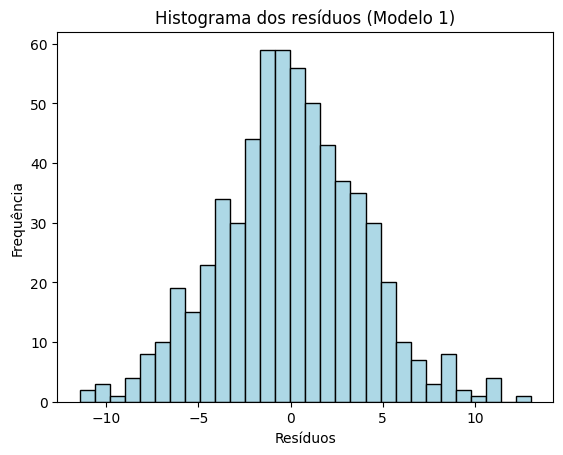

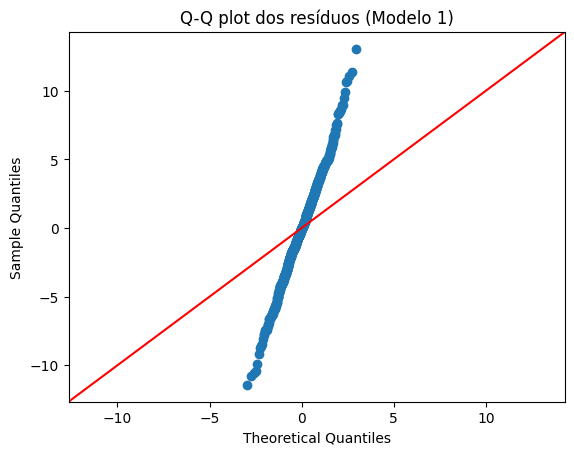

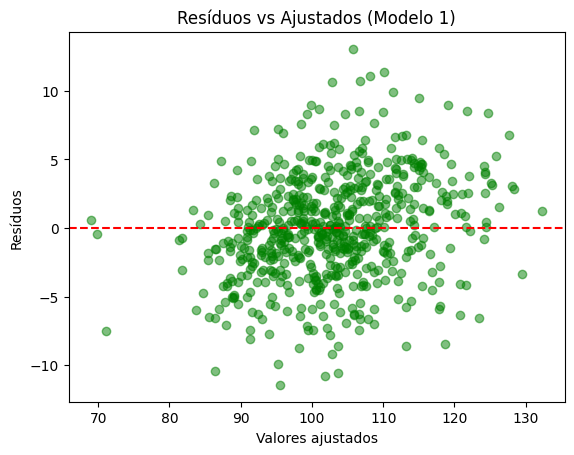

Shapiro-Wilk: 0.9971924935011225 0.37237857231996696
Kolmogorov-Smirnov: 0.02918160042680379 0.6574733346843229


In [25]:
# Análise dos pressupostos do modelo
# Esta célula avalia linearidade, normalidade e homocedasticidade dos resíduos e dos efeitos aleatórios.

# Resíduos do modelo 1
residuals1 = mixed_model1.resid
fitted1 = mixed_model1.fittedvalues

# Histograma dos resíduos
plt.hist(residuals1, bins=30, color='lightblue', edgecolor='black')
plt.title('Histograma dos resíduos (Modelo 1)')
plt.xlabel('Resíduos')
plt.ylabel('Frequência')
plt.show()

# Q-Q plot dos resíduos
sm.qqplot(residuals1, line='45')
plt.title('Q-Q plot dos resíduos (Modelo 1)')
plt.show()

# Resíduos vs valores ajustados
plt.scatter(fitted1, residuals1, alpha=0.5, color='green')
plt.axhline(0, color='red', linestyle='--')
plt.title('Resíduos vs Ajustados (Modelo 1)')
plt.xlabel('Valores ajustados')
plt.ylabel('Resíduos')
plt.show()

# Teste de normalidade (Shapiro-Wilk)
stat, p = shapiro(residuals1)
print('Shapiro-Wilk:', stat, p)

# Teste de normalidade (Kolmogorov-Smirnov)
stat, p = kstest(residuals1, 'norm', args=(residuals1.mean(), residuals1.std()))
print('Kolmogorov-Smirnov:', stat, p)


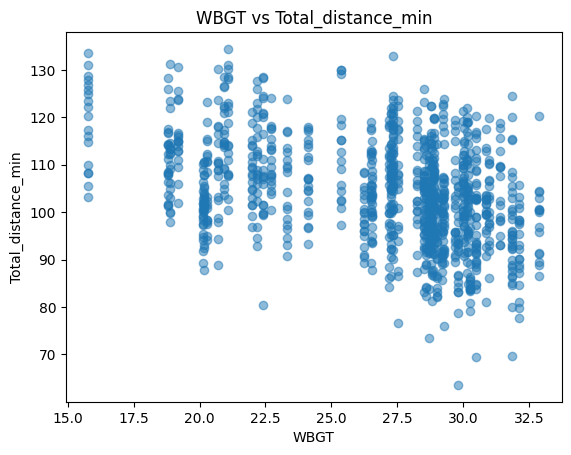

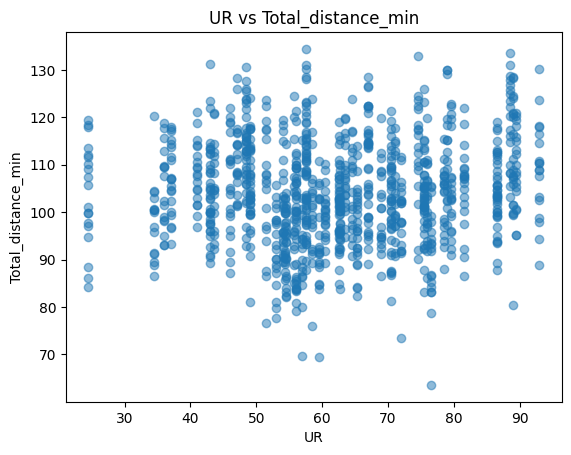

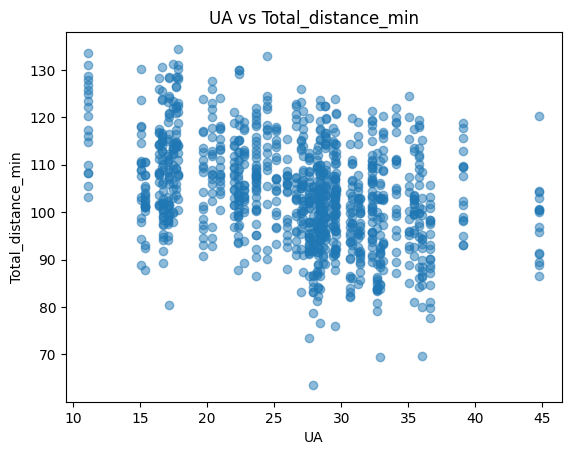

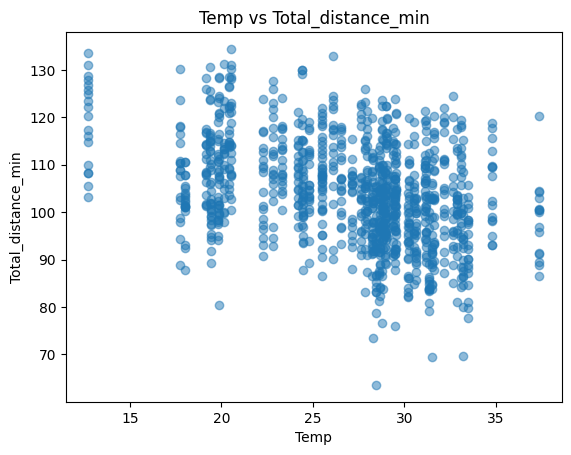

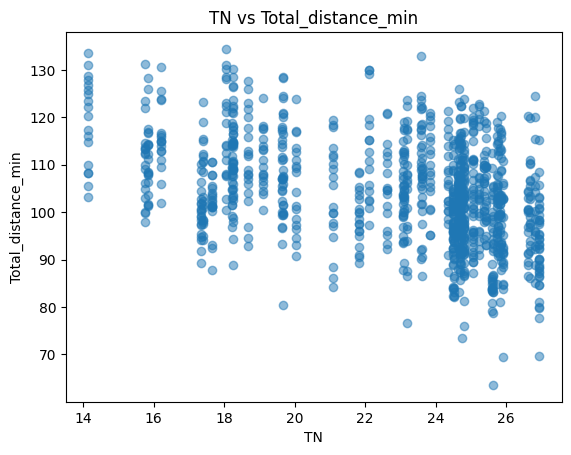

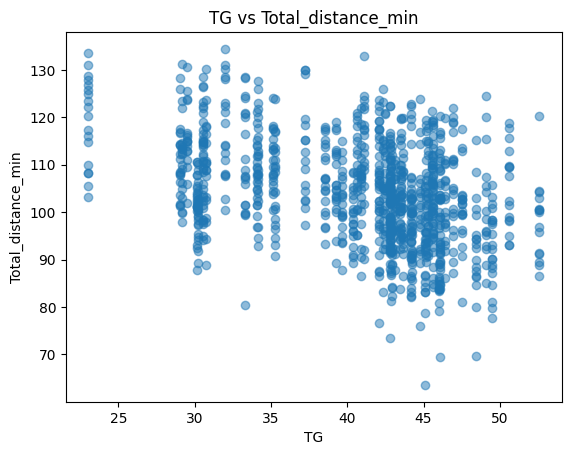

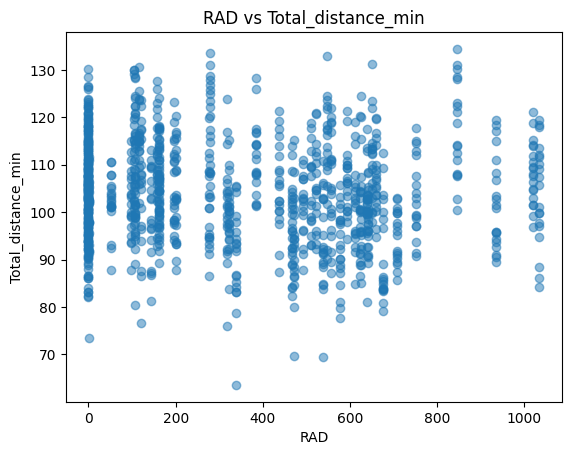

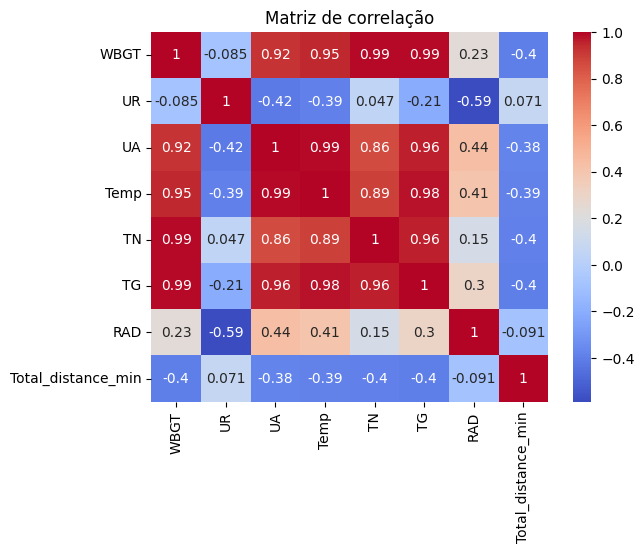

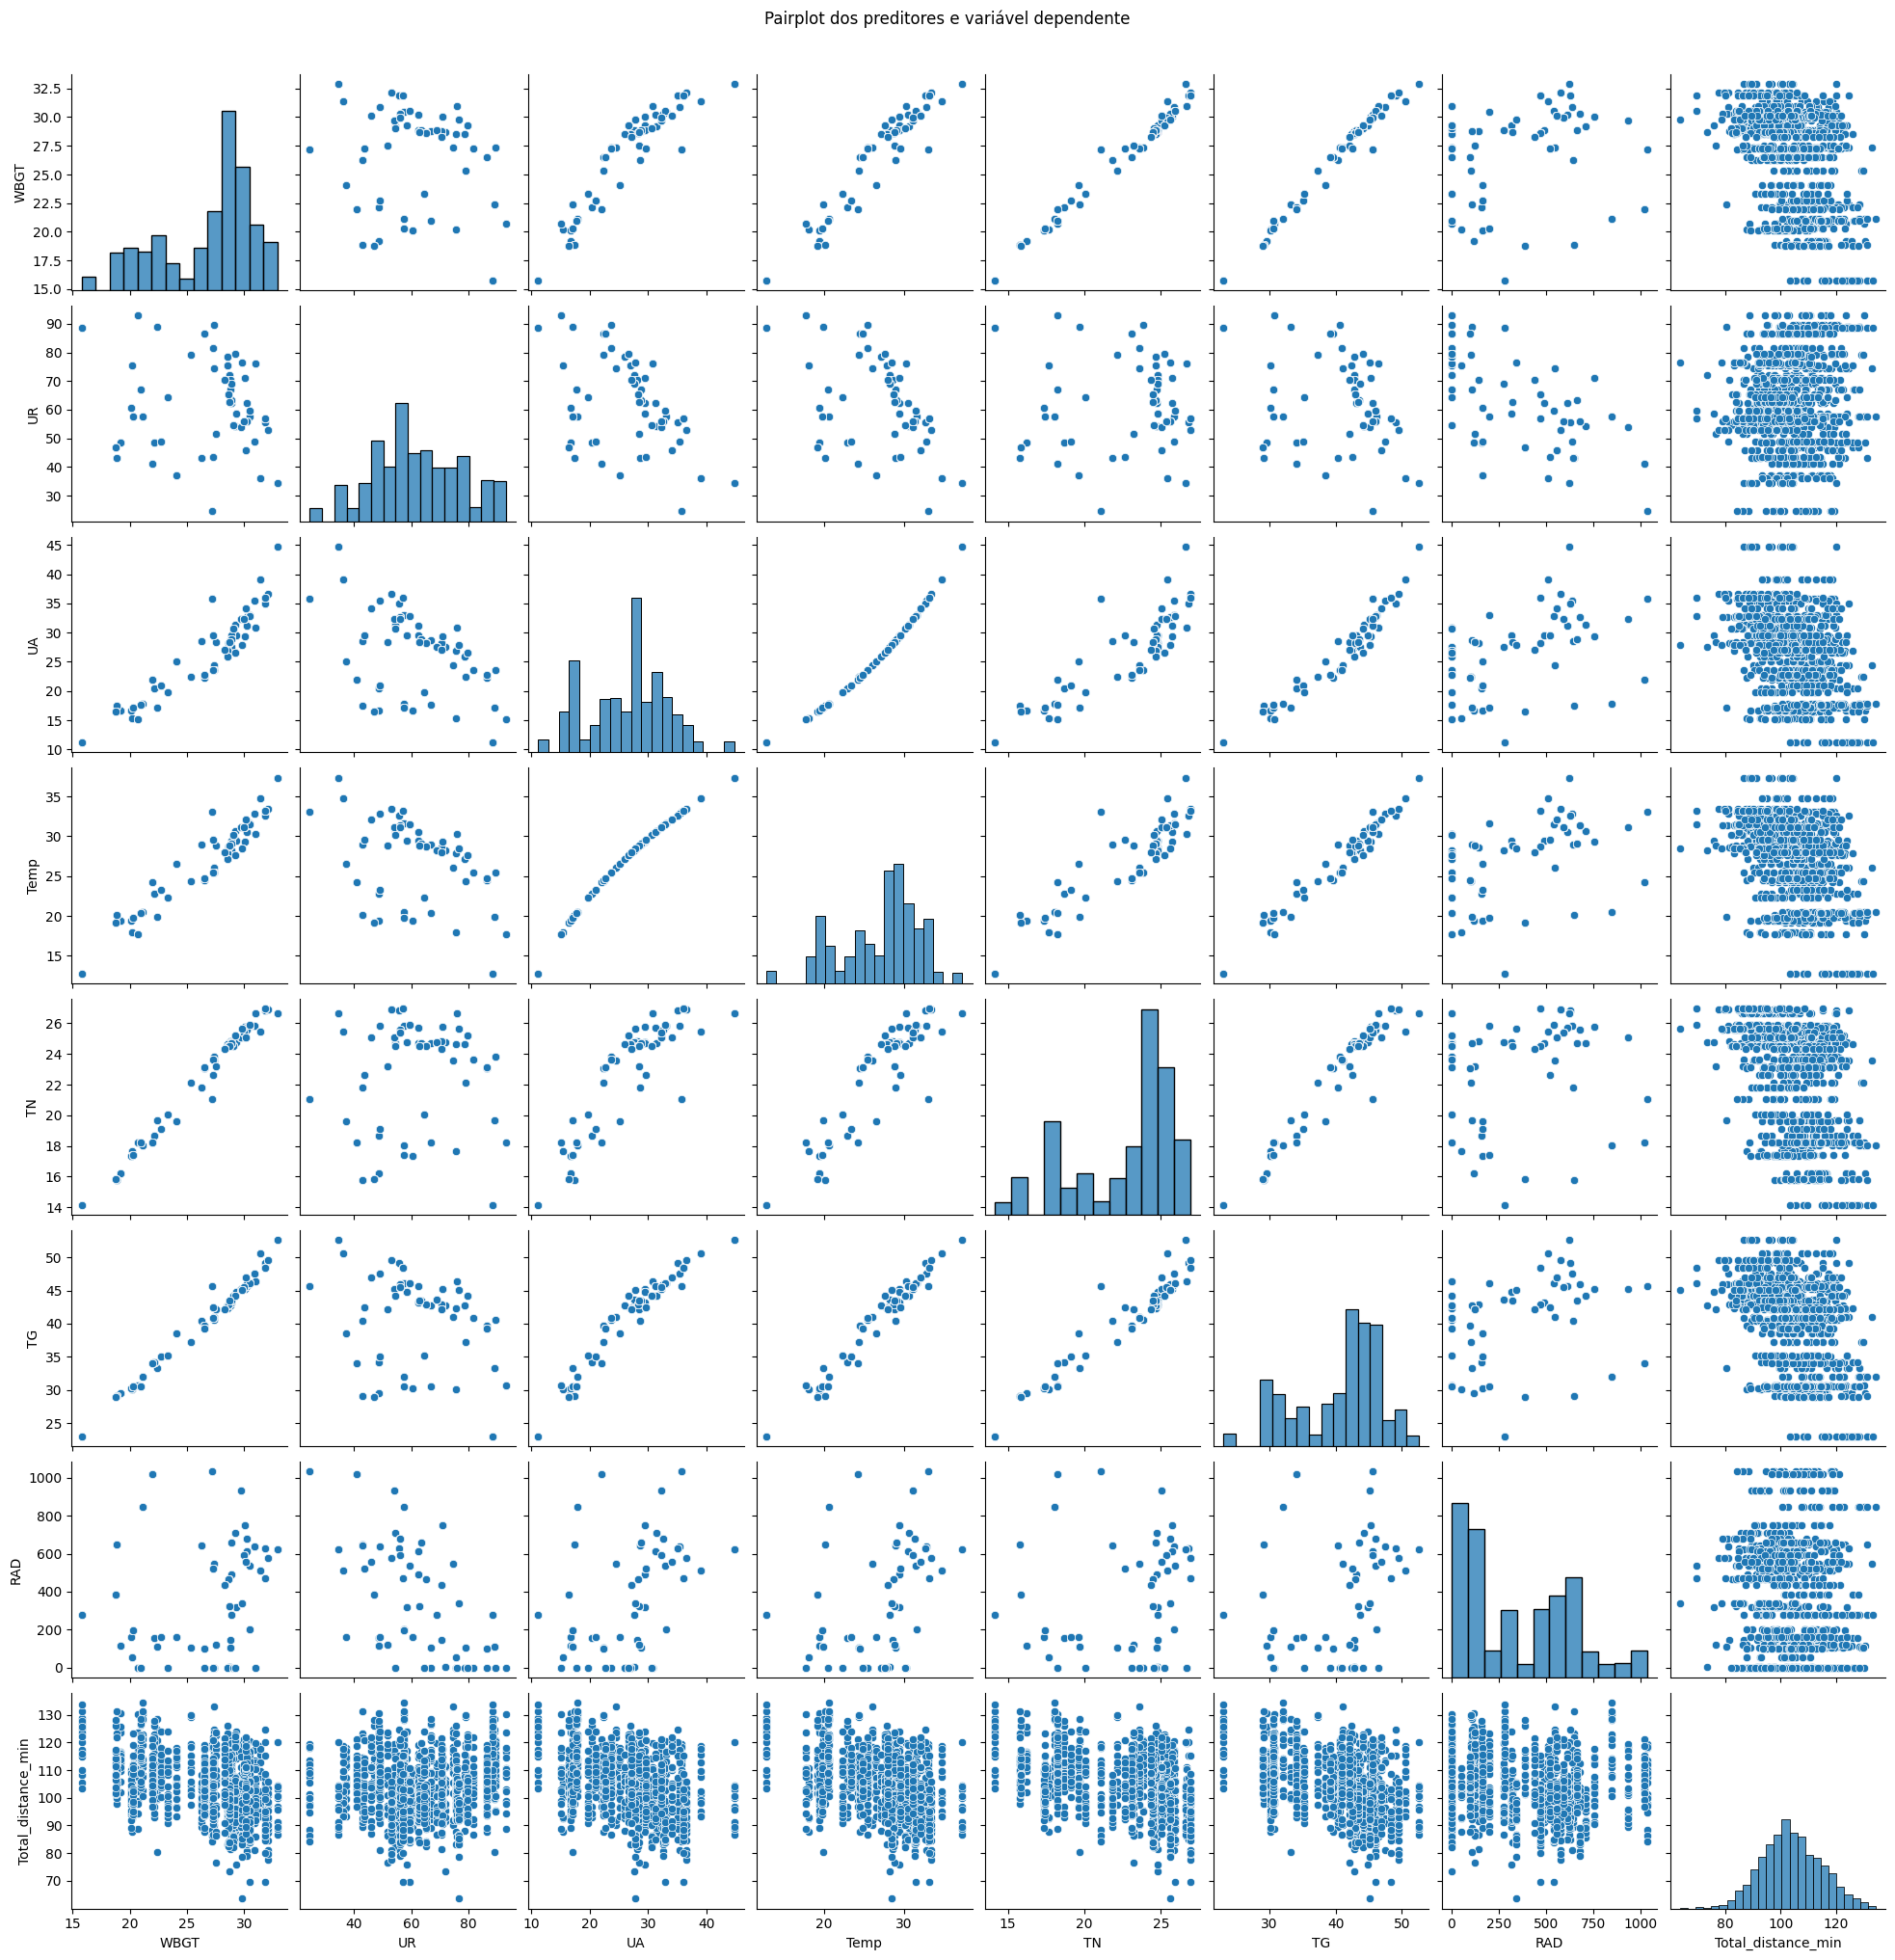

Correlação de Pearson entre WBGT e Total_distance_min: -0.401
Correlação de Pearson entre UR e Total_distance_min: 0.071
Correlação de Pearson entre UA e Total_distance_min: -0.380
Correlação de Pearson entre Temp e Total_distance_min: -0.387
Correlação de Pearson entre TN e Total_distance_min: -0.396
Correlação de Pearson entre TG e Total_distance_min: -0.396
Correlação de Pearson entre RAD e Total_distance_min: -0.091


In [26]:
# Visualização de relações entre variáveis
# Esta célula cria scatterplots, matriz de correlação e pairplot para explorar as relações VD x VI.

# Lista de preditores
predictor_vars = ['WBGT', 'UR', 'UA', 'Temp', 'TN', 'TG', 'RAD']

# Scatterplots
for var in predictor_vars:
    if var in df.columns:
        plt.scatter(df[var], df['Total_distance_min'], alpha=0.5)
        plt.title(f'{var} vs Total_distance_min')
        plt.xlabel(var)
        plt.ylabel('Total_distance_min')
        plt.show()

# Matriz de correlação
corr = df[predictor_vars + ['Total_distance_min']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Matriz de correlação')
plt.show()

# Pairplot
sns.pairplot(df[predictor_vars + ['Total_distance_min']])
plt.suptitle('Pairplot dos preditores e variável dependente', y=1.02)
plt.show()

# Tabela de correlação de Pearson
for var in predictor_vars:
    if var in df.columns:
        r = df[[var, 'Total_distance_min']].corr().iloc[0,1]
        print(f'Correlação de Pearson entre {var} e Total_distance_min: {r:.3f}')


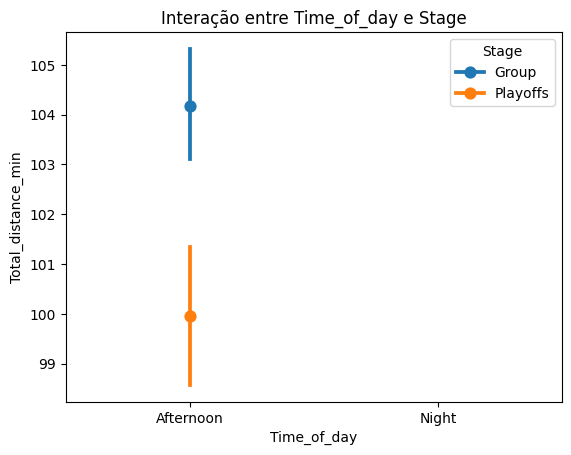

In [27]:
# Análise de efeitos marginais estimados (Estimated Marginal Means)
# Esta célula calcula e plota efeitos marginais estimados e interações, similar ao uso de emmeans no R.

from statsmodels.stats.anova import anova_lm
# Para interações categórica x categórica ou categórica x numérica, use statsmodels ou pymer4
# Exemplo: Efeito marginal de Time_of_day sobre Total_distance_min
# (Necessário ajustar modelo apropriado e usar get_margeff ou equivalente)
# Veja documentação de statsmodels para mais detalhes sobre marginais

# Gráfico de interação (exemplo)
sns.pointplot(x='Time_of_day', y='Total_distance_min', hue='Stage', data=df)
plt.title('Interação entre Time_of_day e Stage')
plt.show()

# Para efeitos marginais de variáveis contínuas, use statsmodels ou pymer4 conforme documentação
